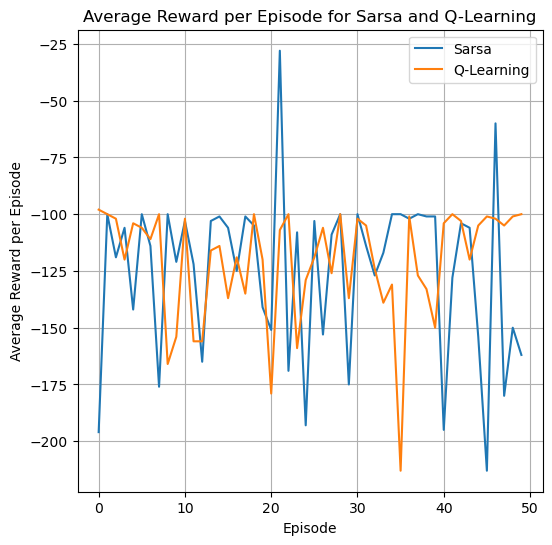

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import random

class CliffWalkingEnv:
    def __init__(self, width=12, height=4):
        self.width = width
        self.height = height
        self.start_state = (0, 0)
        self.goal_state = (width - 1, 0)
        self.cliff_states = [(i, 0) for i in range(1, width - 1)]
        self.action_space = [0, 1, 2, 3]  # 0: up, 1: right, 2: down, 3: left
        self.num_actions = len(self.action_space)
        self.current_state = self.start_state

    def reset(self):
        self.current_state = self.start_state
        return self.current_state

    def step(self, action):
        x, y = self.current_state
        next_x, next_y = x, y
        if action == 0:  # up
            next_y = min(y + 1, self.height - 1)
        elif action == 1:  # right
            next_x = min(x + 1, self.width - 1)
        elif action == 2:  # down
            next_y = max(y - 1, 0)
        elif action == 3:  # left
            next_x = max(x - 1, 0)
        else:
            raise ValueError("Invalid action")

        next_state = (next_x, next_y)
        self.current_state = next_state
        reward = -1
        done = False

        if next_state in self.cliff_states:
            reward = -100
            done = True
            self.current_state = self.start_state
        elif next_state == self.goal_state:
            done = True

        return next_state, reward, done

def epsilon_greedy_policy(Q, state, epsilon, num_actions):
    if random.random() < epsilon:
        return random.choice(range(num_actions))  # Explore
    else:
        return np.argmax(Q[state])  # Exploit

def sarsa(env, alpha=0.1, gamma=0.9, epsilon_start=0.1, epsilon_end=0.5, epsilon_decay_rate=0.001, num_episodes=500):
    Q = np.zeros((env.height * env.width, env.num_actions))
    rewards_per_episode = []
    epsilon = epsilon_start

    for episode in range(num_episodes):
        state = env.reset()
        total_reward = 0
        done = False
        action = epsilon_greedy_policy(Q, state[1] * env.width + state[0], epsilon, env.num_actions) # Corrected state indexing

        while not done:
            next_state, reward, done = env.step(action)
            next_action = epsilon_greedy_policy(Q, next_state[1] * env.width + next_state[0], epsilon, env.num_actions) # Corrected next_state indexing

            target = reward + gamma * Q[next_state[1] * env.width + next_state[0], next_action] if not done else reward # Corrected next_state indexing
            td_error = target - Q[state[1] * env.width + state[0], action] # Corrected state indexing
            Q[state[1] * env.width + state[0], action] += alpha * td_error # Corrected state indexing

            state = next_state
            action = next_action
            total_reward += reward

        rewards_per_episode.append(total_reward)
        epsilon = max(epsilon_end, epsilon - epsilon_decay_rate)

    return Q, rewards_per_episode

def q_learning(env, alpha=0.1, gamma=0.9, epsilon_start=0.1, epsilon_end=0.5, epsilon_decay_rate=0.001, num_episodes=500):
    Q = np.zeros((env.height * env.width, env.num_actions))
    rewards_per_episode = []
    epsilon = epsilon_start

    for episode in range(num_episodes):
        state = env.reset()
        total_reward = 0
        done = False

        while not done:
            action = epsilon_greedy_policy(Q, state[1] * env.width + state[0], epsilon, env.num_actions) # Corrected state indexing
            next_state, reward, done = env.step(action)

            target = reward + gamma * np.max(Q[next_state[1] * env.width + next_state[0]]) if not done else reward # Corrected next_state indexing
            td_error = target - Q[state[1] * env.width + state[0], action] # Corrected state indexing
            Q[state[1] * env.width + state[0], action] += alpha * td_error # Corrected state indexing

            state = next_state
            total_reward += reward

        rewards_per_episode.append(total_reward)
        epsilon = max(epsilon_end, epsilon - epsilon_decay_rate)

    return Q, rewards_per_episode

if __name__ == "__main__":
    env = CliffWalkingEnv()
    num_episodes =50
    

    # Run Sarsa
    sarsa_Q, sarsa_rewards = sarsa(env, num_episodes=num_episodes)
#     sarsa_optimal_path, sarsa_final_reward = get_optimal_path(sarsa_Q, CliffWalkingEnv())

    # Run Q-Learning
    q_learning_Q, q_learning_rewards = q_learning(env, num_episodes=num_episodes)
#     q_learning_optimal_path, q_learning_final_reward = get_optimal_path(q_learning_Q, CliffWalkingEnv())


    # Plotting the rewards per episode
    plt.figure(figsize=(6,6))
    plt.plot(sarsa_rewards, label='Sarsa')
    plt.plot(q_learning_rewards, label='Q-Learning')
    plt.xlabel('Episode')
    plt.ylabel('Average Reward per Episode')
    plt.title('Average Reward per Episode for Sarsa and Q-Learning')
    plt.legend()
    plt.grid(True)
    plt.show()
    